*¿Cuantos registros hay?*

-En total hay 1760 registro, sus dimensiones son 1760 x 7


In [ ]:
import pandas as pd 
from fileinput import filename

df = pd.read_csv("../data/marmara2.csv")

df.shape
df.head()

,total_length_cm,body_depth_cm,body_width_cm,head_length_cm,eye_diameter_mm,weight_gr,species
0,7.9,1.2,0.5,1.9,2.2,3.2,Hamsi
1,13.7,2.1,1.0,2.9,3.4,15.0,Hamsi
2,18.5,3.8,1.9,4.4,4.9,47.9,Sardalya
3,12.1,2.3,1.1,3.0,3.7,15.7,İstavrit
4,7.6,1.4,0.6,1.8,1.9,3.5,İstavrit


En el dataset que encontre hay filas como total_length_cm, body_depth_cm, body_with_cm, head_length_cm, eye_diemeter_mm, weight_gr y species, en este casospecies es el unico valor con cadena de texto de ahi en fuera todos son float

-------------------------------------------------------------------------------------------------------
*¿Están todas las filas completas ó tenemos campos con valores nulos? En caso que haya demasiados nulos: ¿Queda el resto de información inútil?*

-No hay datos nulos de hecho todo el dateset esta completo

In [11]:
print(df.isnull().sum())

total_length_cm    0
body_depth_cm      0
body_width_cm      0
head_length_cm     0
eye_diameter_mm    0
weight_gr          0
species            0
dtype: int64


Al imprimir 'isnull()' me muestra una tablita de las columnas con cuantos valores nulos hay, en este caso no hay ningun valor que falte, dependiendo si falta un dato la informacion puede quedar inutil pero en general la mayoria de dayos es importante por no decir todos 

-----------------------------------------------------------------------------
*¿Que datos son discretos y cuales continuos? Muchas veces sirve obtener el tipo de datos: texto, int, double, float.*

-Todos los datos son continuos ya que son valores mediblles dentro del rango y en genral los discretos son flotantes 


In [ ]:
df.describe()
df.dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1760 entries, 0 to 1759
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   total_length_cm  1760 non-null   float64
 1   body_depth_cm    1760 non-null   float64
 2   body_width_cm    1760 non-null   float64
 3   head_length_cm   1760 non-null   float64
 4   eye_diameter_mm  1760 non-null   float64
 5   weight_gr        1760 non-null   float64
 6   species          1760 non-null   str    
dtypes: float64(6), str(1)
memory usage: 96.4 KB


En este caso todos son float64, y si todos son continuos ya que son cm, mm, gr a excepcion de species que son string (texto)

------------------------------------------------------------------------------------------------------------------------
*Si es un problema supervisado (binaria/multiclase, balanceo de la clase) o un problema no supervisado* 

-Es un problema supervisado ya que me esta dando el nombre de los pescados, y tambien es multiclase por que tengo varios tipos de pescados como el Hamsi, istsvrit, sedalya, mazgit... sin embargo esta un poco desbalancedo ya que hay 500 registros de la clase Hamsi mientras que de Kalkan hay tan solo 30 registros, por lo que al entrenar el modelo no esta aprendiendo correctamente ya que hay mas registros de un pescado que de otros


In [18]:
df['species'].value_counts()

species
Hamsi       500
İstavrit    350
Sardalya    300
Mezgit      150
Palamut     120
Tekir       100
Lüfer        80
İzmarit      80
Zargana      50
Kalkan       30
Name: count, dtype: int64

Con esta funcion me hes posible clasificar todos los registros y observar cuantos registros tiene cada tipo de pescadito

-------------------------------------------------------------------------------------
*¿Cuales parecen ser características importantes? ¿Cuales podemos descartar?*

-De hecho todas son importantes ya que es un dataset pequeñito, a mi punto de vista la 'species' es la mas importante ya que al saber el nombre del pescado uno mas o menos tiene la idea de las dimensiones del pescado, las longitudes tambien son caracteristicas importantes y a mi parecer el diametro de los ojos es un poco irrelevante pero interesante

In [24]:

correlations = df.drop('species', axis=1).corr()
print(correlations)

                 total_length_cm  body_depth_cm  body_width_cm  \
total_length_cm         1.000000       0.676050       0.851461   
body_depth_cm           0.676050       1.000000       0.666988   
body_width_cm           0.851461       0.666988       1.000000   
head_length_cm          0.981028       0.652312       0.762979   
eye_diameter_mm         0.932015       0.537166       0.791972   
weight_gr               0.699304       0.901878       0.692010   

                 head_length_cm  eye_diameter_mm  weight_gr  
total_length_cm        0.981028         0.932015   0.699304  
body_depth_cm          0.652312         0.537166   0.901878  
body_width_cm          0.762979         0.791972   0.692010  
head_length_cm         1.000000         0.931717   0.657353  
eye_diameter_mm        0.931717         1.000000   0.535336  
weight_gr              0.657353         0.535336   1.000000  


-Si hay varias correlaciones y la mayoria depende de datos entre si

-------------------------------------------------------------------------------------------------
*¿Siguen alguna distribución? ¿Hay correlación entre características?* 

-Si hay correlaciones, algunas son mas fuertes y otras mas bajitas pero la mayoria esta por encima de los 0.50, eso quiere decir que todos los datos son importantes y que se complementan entre si

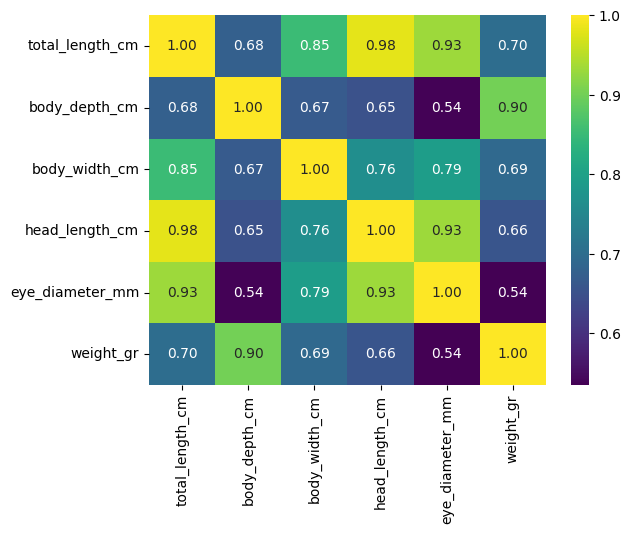

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

correlations = df.drop('species', axis=1).corr()

sns.heatmap(correlations, annot=True, cmap='viridis', fmt=".2f")
plt.show()

Aqui los que estan mas relacionados obviamente pues los que son igualitos, eso si no tiene mucho que ver, pero los que sin estan muy relacionados es head_length_cm -> total_length_cm de ahi le sigue eye_diameeter_mm -> total_length_cm & head_length_cm -> eye_length_cm y de los menos relacionados son eye_diameter_mm -> body_depth_cm & eye_diameter_mm con weigth_gr, algun punto clave es que los peces de mayor tamaño tienden a presentar mayores dimensiones corporales y peso.

---------------------------------------------------------------------------------------------
*Cuales son los Outliers? (unos pocos datos aislados que difieren drásticamente del resto y «contaminan» ó desvían las distribuciones)*

-En el diagrama me esta mostrando que no hay datos atipicos (outliers), ya que los puntitos que son los outliers no estan muy sepados eso quiere decir que no hay muchos datos atipicos, al hacer el otro esquema se observa con mayor detenimiento



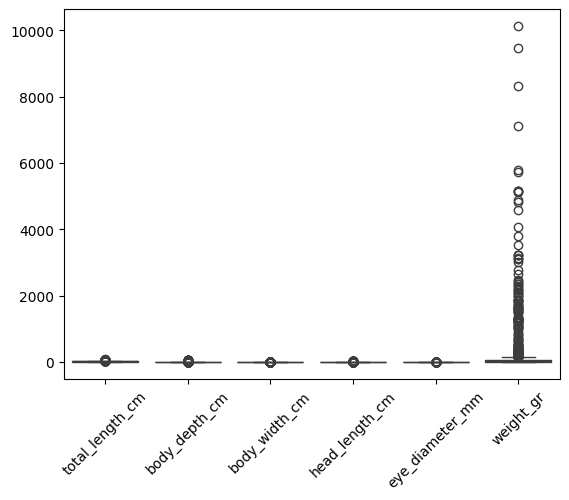

In [26]:
sns.boxplot(data=df.drop('species', axis=1))
plt.xticks(rotation=45)
plt.show()

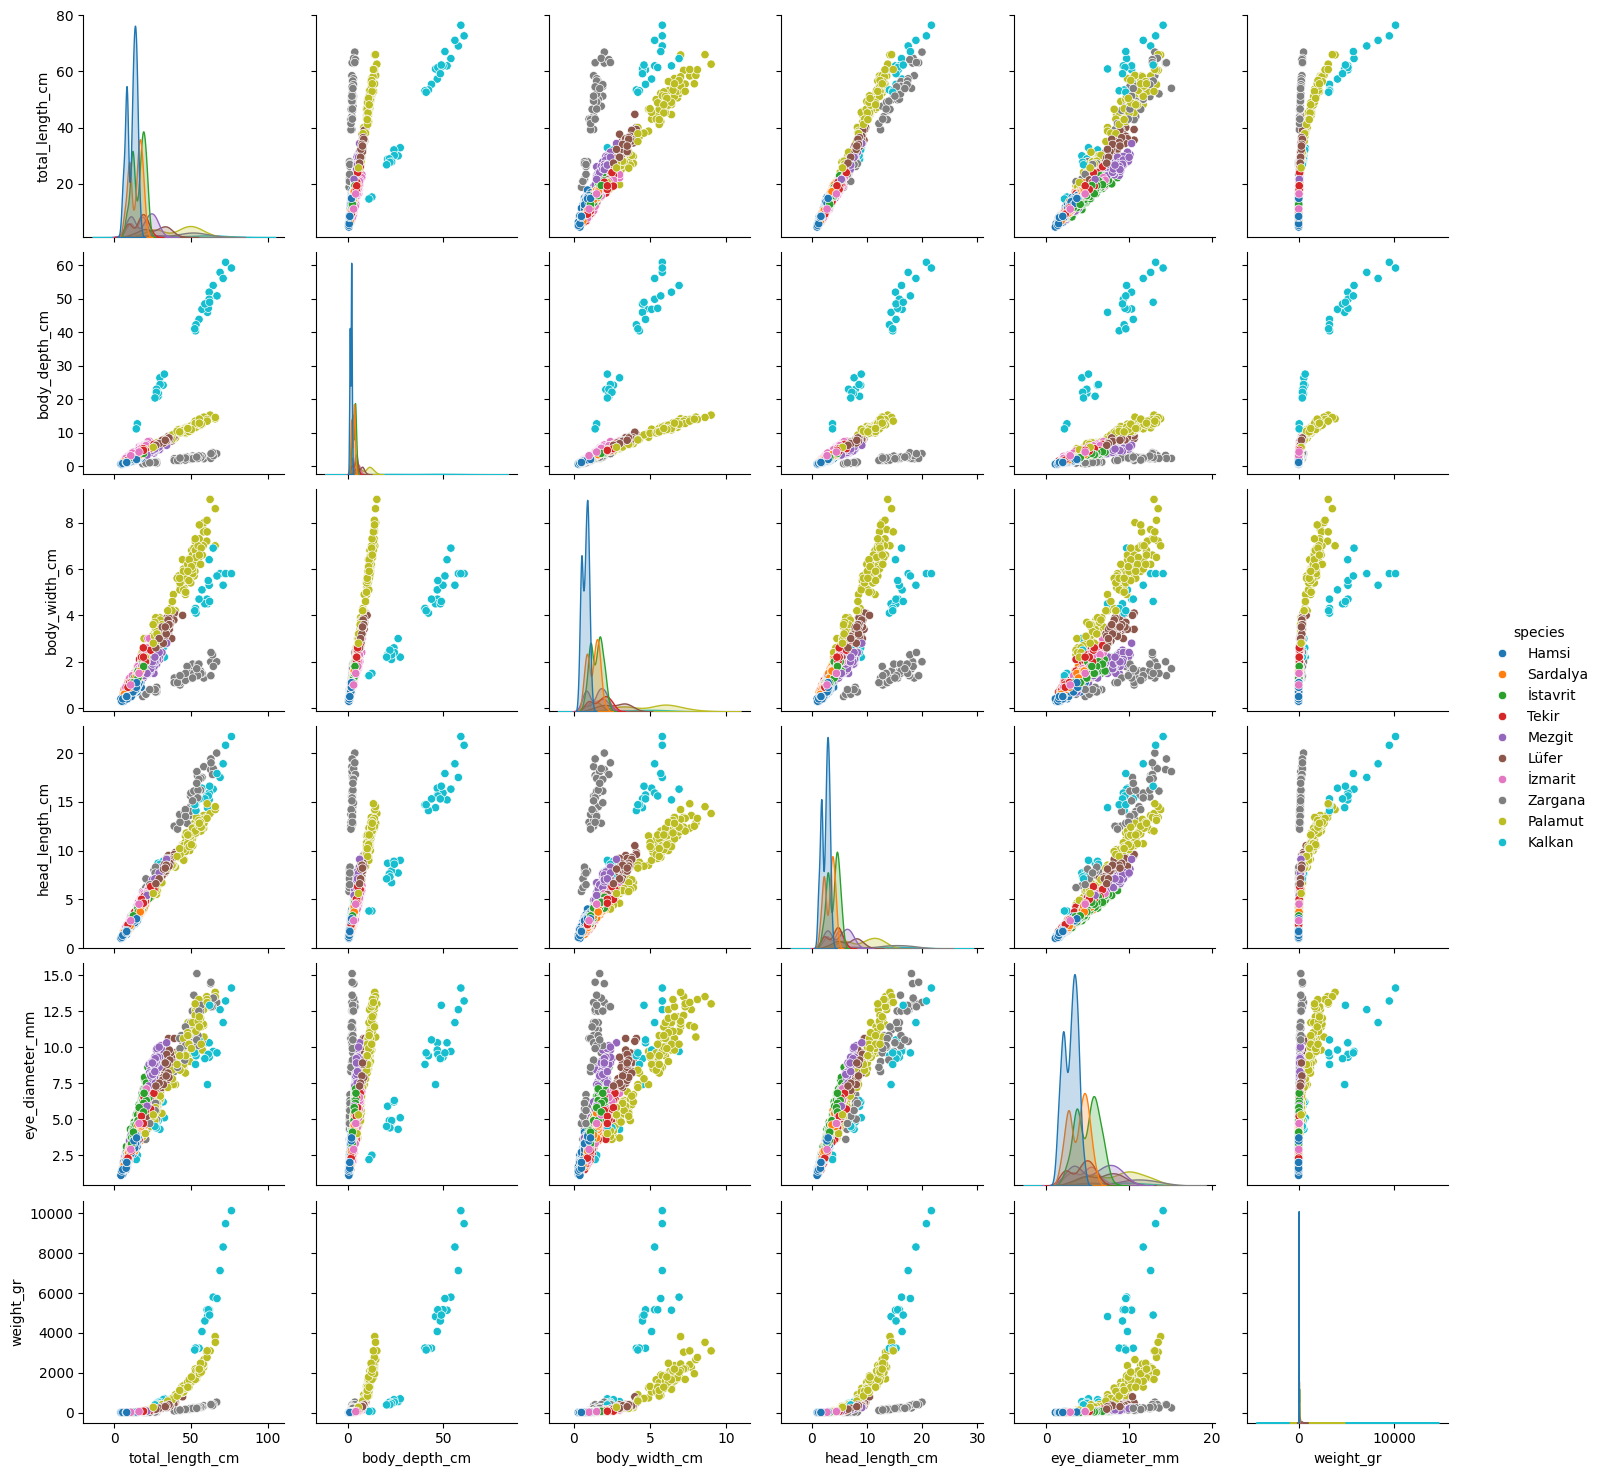

In [27]:
sns.pairplot(df, hue='species')
plt.show()

------------------------------------------------------------------------
*¿Tenemos posible sesgo de datos?*

-Al parecer si hay sesgo de datos, entre clases si se nota mucho, como se decia anteriormente hamsi es el que tiene mas registros, entonces  al observar el otro diagrama se puede ver que hay mayor sesgo en la parte derecha, eso quiere decir que es un sesgo positivo ya que esta a la derecha en todas

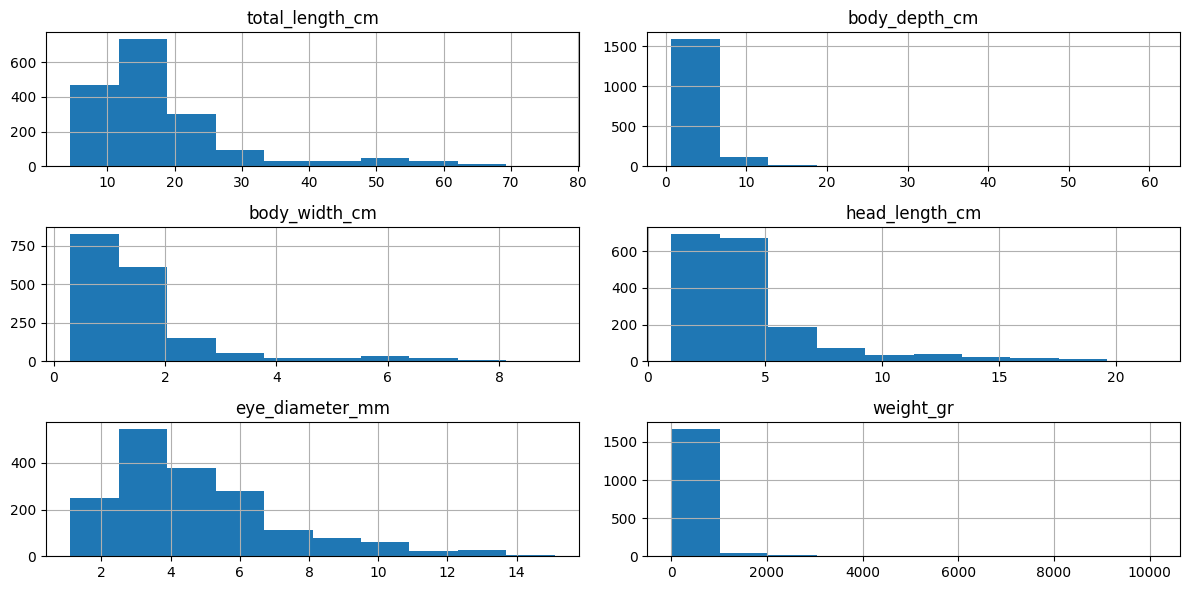

In [28]:
df.drop('species', axis=1).hist(figsize=(12,6))
plt.tight_layout()
plt.show()

Aqui se muestra como en absolutamente en todos los histogramas se ve mayor peso en la parte derecha y un poquito por en medio :3